# 03 — Journal Figure Generation

**Journal:** Biosystems Engineering (Elsevier)  
**Requirements:** ≥300 dpi, TIFF preferred, left+bottom axes only, serif font, no title on figures  
**Dependencies:** `matplotlib`, `scipy`, `statsmodels`, `Pillow` — all standard, **no plotly/kaleido needed**  

This notebook:
1. Loads the processed parquet files (same pipeline as `01_ingest_EDA` and `02_analysis`)
2. Computes delta-t, idle classification, ANOVA/Tukey
3. Exports 4 publication-ready figures as TIFF + PNG

In [13]:
# ==========================================================================
# CELL 1: Imports & Configuration
# ==========================================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# --- Path Configuration (same logic as NB1 and NB2) ---
CURRENT_PATH = Path.cwd()
if CURRENT_PATH.name == 'notebooks':
    PROJECT_ROOT = CURRENT_PATH.parent
else:
    PROJECT_ROOT = CURRENT_PATH

DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'reports' / 'journal_figures'
FIG_DIR.mkdir(exist_ok=True, parents=True)

# --- Journal Style (Global) ---
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,   # journal: only left + bottom axes
    'axes.spines.right': False,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'figure.dpi':        150,     # screen preview
    'savefig.dpi':       300,     # export
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.05,
})

# --- Constants ---
DIESEL_PRICE       = 1.588   # EUR/L (Germany 2024)
EMISSION_FACTOR    = 2.64    # kg CO2e per litre (IPCC)
SPEED_THRESHOLD    = 0.75    # m/s
RPM_ON_THRESHOLD   = 100     # rev/min
PTO_ACTIVE_THRESH  = 150     # rev/min
MIN_IDLE_DURATION  = 0       # seconds
SAMPLE_SIZE        = 500_000
TOP_N_ACTIVITIES   = 12

# --- Activity Translation (ALC original -> manuscript English) ---
ACTIVITY_MAP = {
    'Cultivating (deep)':     'Deep cultivation',
    'Cultivating (shallow)':  'Shallow cultivation',
    'Disc harrowing':         'Harrowing',
    'Fertilizing':            'Fertilising',       # UK English
    'Mowing (front)':         'Mowing (front)',
    'Mowing (large-scale)':   'Mowing (large-scale)',
    'Mulching':               'Mulching',
    'Ploughing':              'Ploughing',
    'Power harrowing':        'Rotary harrowing',
    'Seed drill combination': 'Combined sowing',
    'Seedbed combination':    'Seedbed preparation',
    'Spraying':               'Spraying',
    'Transport':              'Transport',
    'not working':            'Not Working',
}

print(f'Project root  : {PROJECT_ROOT}')
print(f'Data dir      : {DATA_DIR}')
print(f'Figure output : {FIG_DIR}')
print(f'Matplotlib    : {matplotlib.__version__}')

Project root  : e:\Tese\idletime
Data dir      : e:\Tese\idletime\data\processed
Figure output : e:\Tese\idletime\reports\journal_figures
Matplotlib    : 3.10.7


In [14]:
# ==========================================================================
# CELL 2: Data Loading  (mirrors 02_analysis Cell 2)
# ==========================================================================
part_files = sorted(DATA_DIR.glob('*_processed.parquet'))

if not part_files:
    print('No partial files found. Trying telemetry_full.parquet...')
    df = pd.read_parquet(DATA_DIR / 'telemetry_full.parquet')
else:
    print(f'Found {len(part_files)} processed parquet files:')
    for f in part_files:
        print(f'  -> {f.name}')
    df = pd.concat([pd.read_parquet(f) for f in part_files], ignore_index=True)

# Sort for temporal consistency
df.sort_values(by=['tractor', 'source_file', 'timestamp'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Delta-t
df['delta_t'] = df.groupby(['tractor', 'source_file'])['timestamp'].diff().fillna(0)
df.loc[df['delta_t'] > 300, 'delta_t'] = 0   # >5 min gap = engine off
df.loc[df['delta_t'] < 0,   'delta_t'] = 0   # safety

# Fuel consumed per record
df['liters_consumed'] = (df['fuel_rate'] * df['delta_t']) / 3600.0

# Activity English labels
df['activity_en'] = df['activity'].map(ACTIVITY_MAP).fillna(df['activity'])

total_recs  = len(df)
total_hours = df['delta_t'].sum() / 3600
total_L     = df['liters_consumed'].sum()

print(f'\nRecords : {total_recs:,}')
print(f'Hours   : {total_hours:,.1f} h')
print(f'Diesel  : {total_L:,.1f} L')
print(f'Tractors: {sorted(df["tractor"].unique())}')
print(f'Columns : {list(df.columns)}')

Found 5 processed parquet files:
  -> Fendt 211_processed.parquet
  -> Fendt 314_processed.parquet
  -> Fendt 722_processed.parquet
  -> Fendt 724_processed.parquet
  -> Fendt 820_processed.parquet

Records : 31,033,670
Hours   : 881.4 h
Diesel  : 11,310.1 L
Tractors: ['Fendt 211', 'Fendt 314', 'Fendt 722', 'Fendt 724', 'Fendt 820']
Columns : ['timestamp', 'tractor', 'activity', 'field', 'fuel_rate', 'veh_speed', 'engine_rpm', 'status', 'latitude', 'longitude', 'cluster_id', 'front_hitch_pos', 'pto_rpm', 'engine_torque', 'hitch_pos', 'source_file', 'delta_t', 'liters_consumed', 'activity_en']


In [15]:
# ==========================================================================
# CELL 3: Idle Classification  (mirrors 02_analysis Cell 7)
# ==========================================================================
print('--- Event-Based Idle Classification ---\n')

mask_off       = df['engine_rpm'] < RPM_ON_THRESHOLD
mask_low_speed = df['veh_speed']  < SPEED_THRESHOLD
mask_pto_off   = df['pto_rpm'].fillna(0) < PTO_ACTIVE_THRESH

df['state_raw'] = 'Working'
df.loc[mask_off, 'state_raw'] = 'Off'
df.loc[(~mask_off) & mask_low_speed & mask_pto_off, 'state_raw'] = 'Idle_Candidate'

# Event grouping
df['event_id'] = (df['state_raw'] != df['state_raw'].shift()).cumsum()
event_dur = df.groupby('event_id')['delta_t'].transform('sum')

df['state'] = df['state_raw']
df.loc[(df['state_raw'] == 'Idle_Candidate') & (event_dur <  MIN_IDLE_DURATION), 'state'] = 'Working'
df.loc[(df['state_raw'] == 'Idle_Candidate') & (event_dur >= MIN_IDLE_DURATION), 'state'] = 'Idle'

df['fuel_idle'] = 0.0
df.loc[df['state'] == 'Idle', 'fuel_idle'] = df['liters_consumed']

# Report
engine_on_h = df.loc[df['state'] != 'Off', 'delta_t'].sum() / 3600
idle_h      = df.loc[df['state'] == 'Idle', 'delta_t'].sum() / 3600
idle_L      = df['fuel_idle'].sum()

print(f'Engine-on time  : {engine_on_h:,.1f} h')
print(f'Idle time       : {idle_h:,.1f} h  ({100*idle_h/engine_on_h:.1f}%)')
print(f'Idle fuel waste : {idle_L:,.1f} L  ({100*idle_L/total_L:.1f}%)')
print(f'Avoidable CO2e  : {idle_L * EMISSION_FACTOR / 1000:.2f} t')

--- Event-Based Idle Classification ---

Engine-on time  : 807.1 h
Idle time       : 163.0 h  (20.2%)
Idle fuel waste : 453.9 L  (4.0%)
Avoidable CO2e  : 1.20 t


In [16]:
# ==========================================================================
# CELL 4: Tukey CLD Helper  (same as 01_ingest_EDA Cell 9)
# ==========================================================================
def get_tukey_letters(tukey_results, means_sorted):
    """Generate compact-letter display (a, b, c...) from Tukey HSD."""
    labels  = means_sorted.index.tolist()
    letters = {lab: '' for lab in labels}
    res_df  = pd.DataFrame(
        data    = tukey_results.summary().data[1:],
        columns = tukey_results.summary().data[0]
    )
    alphabet     = 'abcdefghijklmnopqrstuvwxyz'
    not_assigned = labels.copy()
    letter_idx   = 0

    while not_assigned:
        base   = not_assigned[0]
        letter = alphabet[letter_idx]
        letters[base] += letter

        for other in not_assigned[1:]:
            pair = res_df[
                ((res_df['group1'] == base) & (res_df['group2'] == other)) |
                ((res_df['group1'] == other) & (res_df['group2'] == base))
            ]
            if not pair.empty and not pair['reject'].values[0]:
                letters[other] += letter

        not_assigned.pop(0)
        letter_idx += 1

    return letters

print('get_tukey_letters() loaded.')

get_tukey_letters() loaded.


In [17]:
# ==========================================================================
# CELL 5: ANOVA + Tukey (Tractors & Activities)
# ==========================================================================

# Filter: engine on + valid fuel
df_clean = df[(df['engine_rpm'] > RPM_ON_THRESHOLD) & (df['fuel_rate'].notnull())].copy()

# ========== TRACTOR ==========
if len(df_clean) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(df_clean)
    df_samp_t = df_clean.groupby('tractor', group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=42)
    )
else:
    df_samp_t = df_clean.copy()

groups_t = [g['fuel_rate'].values for _, g in df_samp_t.groupby('tractor')]
f_t, p_t = stats.f_oneway(*groups_t)
print(f'TRACTOR ANOVA   F = {f_t:,.2f}   p = {p_t:.4e}')

tukey_t   = pairwise_tukeyhsd(df_samp_t['fuel_rate'], df_samp_t['tractor'], alpha=0.05)
summary_t = df_samp_t.groupby('tractor')['fuel_rate'].agg(['mean', 'std']).sort_values('mean', ascending=False)
summary_t['letter'] = summary_t.index.map(get_tukey_letters(tukey_t, summary_t['mean']))

print()
for name, row in summary_t.iterrows():
    print(f'  {name:<15}  {row["mean"]:6.2f} +/- {row["std"]:5.2f} L/h   ({row["letter"]})')

# ========== ACTIVITY ==========
top_acts    = df_clean['activity'].value_counts().head(TOP_N_ACTIVITIES).index.tolist()
df_clean_a  = df_clean[df_clean['activity'].isin(top_acts)].copy()
df_clean_a['activity_en'] = df_clean_a['activity'].map(ACTIVITY_MAP).fillna(df_clean_a['activity'])

if len(df_clean_a) > SAMPLE_SIZE:
    frac_a = SAMPLE_SIZE / len(df_clean_a)
    df_samp_a = df_clean_a.groupby('activity', group_keys=False).apply(
        lambda x: x.sample(frac=frac_a, random_state=42)
    )
else:
    df_samp_a = df_clean_a.copy()

# Ensure activity_en column exists after sampling
df_samp_a['activity_en'] = df_samp_a['activity'].map(ACTIVITY_MAP).fillna(df_samp_a['activity'])

groups_a = [g['fuel_rate'].values for _, g in df_samp_a.groupby('activity')]
f_a, p_a = stats.f_oneway(*groups_a)
print(f'\nACTIVITY ANOVA  F = {f_a:,.2f}   p = {p_a:.4e}')

tukey_a     = pairwise_tukeyhsd(df_samp_a['fuel_rate'], df_samp_a['activity'], alpha=0.05)
sum_a_raw   = df_samp_a.groupby('activity')['fuel_rate'].agg(['mean', 'std']).sort_values('mean', ascending=False)
letters_raw = get_tukey_letters(tukey_a, sum_a_raw['mean'])

# Build summary keyed by English label
summary_a = df_samp_a.groupby('activity_en')['fuel_rate'].agg(['mean', 'std']).sort_values('mean', ascending=False)
map_raw_to_en = {k: ACTIVITY_MAP.get(k, k) for k in letters_raw}
letters_en    = {map_raw_to_en[k]: v for k, v in letters_raw.items()}
summary_a['letter'] = summary_a.index.map(letters_en)

print()
for name, row in summary_a.iterrows():
    print(f'  {name:<25}  {row["mean"]:6.2f} +/- {row["std"]:5.2f} L/h   ({row["letter"]})')

TRACTOR ANOVA   F = 16,072.95   p = 0.0000e+00

  Fendt 820         17.62 +/- 12.72 L/h   (a)
  Fendt 722         17.19 +/- 12.79 L/h   (b)
  Fendt 724         13.18 +/- 14.96 L/h   (c)
  Fendt 314          9.14 +/-  8.53 L/h   (d)
  Fendt 211          4.67 +/-  3.54 L/h   (e)

ACTIVITY ANOVA  F = 16,979.62   p = 0.0000e+00

  Ploughing                   26.06 +/- 12.83 L/h   (a)
  Deep cultivation            25.51 +/- 13.57 L/h   (b)
  Harrowing                   24.19 +/-  8.64 L/h   (c)
  Rotary harrowing            21.53 +/- 14.59 L/h   (d)
  Combined sowing             19.86 +/- 10.27 L/h   (e)
  Seedbed preparation         19.67 +/- 10.43 L/h   (ef)
  Shallow cultivation         18.67 +/-  8.95 L/h   (g)
  Mulching                    15.00 +/-  7.50 L/h   (h)
  Fertilising                 13.67 +/- 10.16 L/h   (i)
  Transport                    9.54 +/- 11.07 L/h   (j)
  Not Working                  8.96 +/- 10.28 L/h   (k)
  Spraying                     7.12 +/-  3.56 L/h   (l)


In [18]:
# ==========================================================================
# CELL 6: Helper — save figure as TIFF + PNG and report
# ==========================================================================
def save_journal_fig(fig, name):
    """Save figure as both TIFF (for submission) and PNG (for preview)."""
    tiff_path = FIG_DIR / f'{name}.tiff'
    png_path  = FIG_DIR / f'{name}.png'
    
    fig.savefig(png_path,  dpi=300, format='png')
    fig.savefig(tiff_path, dpi=300, format='tiff')
    
    img = Image.open(png_path)
    w, h = img.size
    print(f'  -> {name}.tiff + .png  |  {w} x {h} px  |  '
          f'{w/300:.1f} x {h/300:.1f} in @ 300 dpi')

print('save_journal_fig() loaded.')

save_journal_fig() loaded.


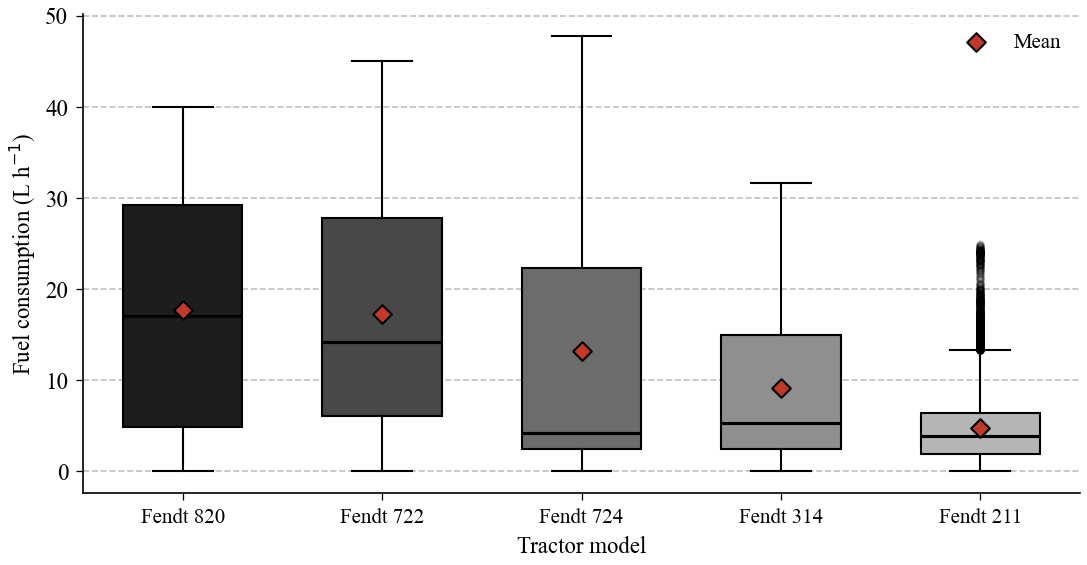

In [25]:
# ==========================================================================
# CELL 7: FIGURE 1 — Boxplot: fuel consumption by tractor
# ==========================================================================
import matplotlib.pyplot as plt
import numpy as np

# Ensure we use a Serif font (Times New Roman is standard for Elsevier/Biosystems)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# 1. Data Prep
tractor_order = summary_t.index.tolist()   # highest -> lowest mean
n_t = len(tractor_order)

# Data arrays in order
data_fig1  = [df_samp_t.loc[df_samp_t['tractor'] == t, 'fuel_rate'].values
              for t in tractor_order]
means_fig1 = [summary_t.loc[t, 'mean'] for t in tractor_order]

# 2. COLOURS: Grayscale Gradient (Dark -> Light)
# 0.9 = Dark Gray, 0.4 = Light Gray. (Avoid 1.0 which is pure black)
greys = plt.cm.Greys(np.linspace(0.9, 0.4, n_t))

# 3. Plotting
fig1, ax1 = plt.subplots(figsize=(190/25.4, 4)) # Width = 190mm (Double Column) approx

bp1 = ax1.boxplot(
    data_fig1, 
    positions=range(1, n_t + 1), 
    patch_artist=True, 
    widths=0.6,
    # Style the lines to be distinct in B&W
    medianprops  = dict(color='black', linewidth=1.5), 
    whiskerprops = dict(linewidth=1.0, color='black'),
    capprops     = dict(linewidth=1.0, color='black'),
    flierprops   = dict(marker='o', markersize=3, markeredgecolor='black', alpha=0.2), # Outliers as empty circles
)

# Apply the Gray Gradient to the boxes
for patch, c in zip(bp1['boxes'], greys):
    patch.set_facecolor(c)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.0)

# 4. Mean Markers (Red Diamond)
# Note: If the journal requires pure B&W, change color='#C0392B' to 'black' or 'white'
ax1.scatter(range(1, n_t + 1), means_fig1,
            marker='D', color='#C0392B', s=40, zorder=5, label='Mean', edgecolors='black')

# 5. Formatting
ax1.set_xticks(range(1, n_t + 1))
ax1.set_xticklabels(tractor_order, fontsize=10)
ax1.set_ylabel('Fuel consumption (L h$^{-1}$)', fontsize=11)
ax1.set_xlabel('Tractor model', fontsize=11)

# Clean grid (Optional, but often looks better in journals)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax1.set_axisbelow(True)

# Legend (Simple)
ax1.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()

# Export
# save_journal_fig(fig1, 'Figure_1_Fuel_Boxplot') # Uncomment when running full notebook
plt.show()

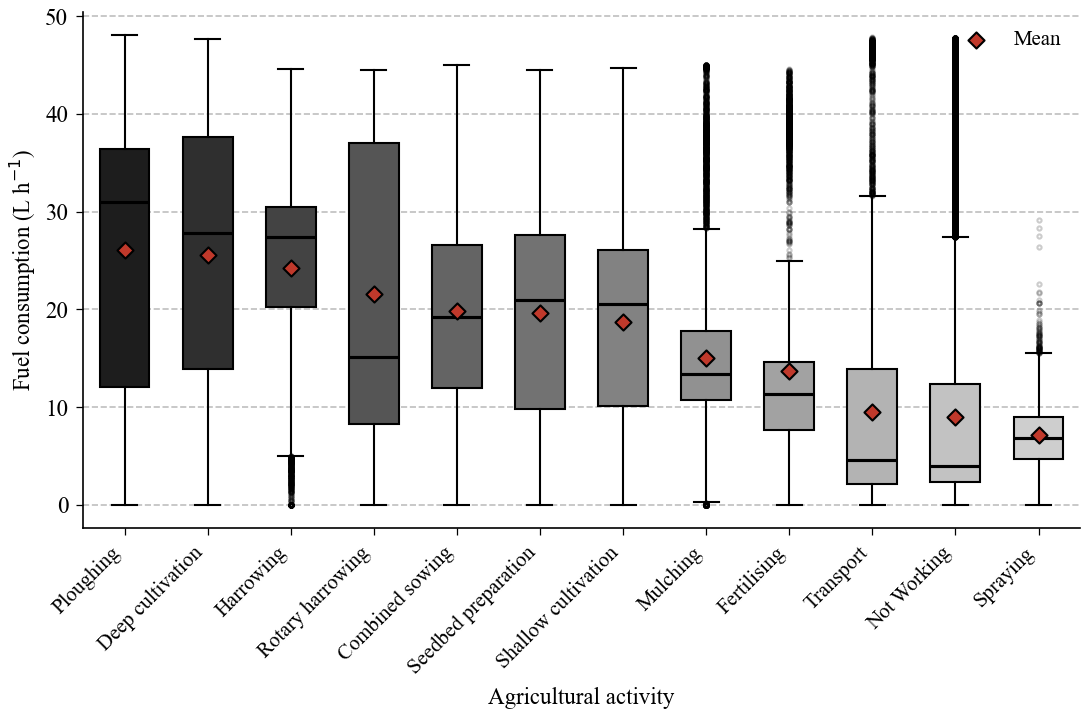

In [26]:
# ==========================================================================
# CELL 8: FIGURE 2 — Boxplot: fuel consumption by activity
# ==========================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
activity_order = summary_a.index.tolist()   # highest -> lowest mean
n_a = len(activity_order)

# Data gathering loop
data_fig2 = []
# We need to map back to original names if the summary uses translated/clean names
# Assuming 'summary_a' uses the clean English names
for act_en in activity_order:
    # If you have a reverse map from a previous cell, use it. 
    # If not, we assume act_en is the value needed.
    # Safe fallback:
    val_to_search = act_en 
    if 'ACTIVITY_MAP' in locals():
        # Find key by value
        found = [k for k, v in ACTIVITY_MAP.items() if v == act_en]
        if found: val_to_search = found[0]
            
    data_fig2.append(
        df_samp_a.loc[df_samp_a['activity'] == val_to_search, 'fuel_rate'].values
    )

means_fig2 = [summary_a.loc[a, 'mean'] for a in activity_order]

# 2. COLOURS: Grayscale Gradient (Dark -> Light)
# 0.9 = Dark, 0.3 = Light. 
# We go a bit lighter (0.3) at the end because there are more bars
greys_a = plt.cm.Greys(np.linspace(0.9, 0.3, n_a))

# 3. Plotting
# Width: 190mm (Standard double column)
fig2, ax2 = plt.subplots(figsize=(190/25.4, 5)) 

bp2 = ax2.boxplot(
    data_fig2, 
    positions=range(1, n_a + 1), 
    patch_artist=True, 
    widths=0.6,
    # Standard Journal Styling
    medianprops  = dict(color='black', linewidth=1.5),
    whiskerprops = dict(linewidth=1.0, color='black'),
    capprops     = dict(linewidth=1.0, color='black'),
    flierprops   = dict(marker='o', markersize=2, markeredgecolor='black', alpha=0.2),
)

# Apply Gray Gradient
for patch, c in zip(bp2['boxes'], greys_a):
    patch.set_facecolor(c)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.0)
    # patch.set_alpha(0.9) # Optional, usually 1.0 is better for print

# 4. Mean Markers (Red Diamond)
ax2.scatter(range(1, n_a + 1), means_fig2,
            marker='D', color='#C0392B', s=30, zorder=5, label='Mean', edgecolors='black')

# 5. Formatting
ax2.set_xticks(range(1, n_a + 1))
ax2.set_xticklabels(activity_order, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Fuel consumption (L h$^{-1}$)', fontsize=11)
ax2.set_xlabel('Agricultural activity', fontsize=11)

# Grid
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax2.set_axisbelow(True)

# Legend
ax2.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()

# Export
# save_journal_fig(fig2, 'Figure_2_Activity_Boxplot')
plt.show()

  -> Figure_3.tiff + .png  |  2008 x 974 px  |  6.7 x 3.2 in @ 300 dpi


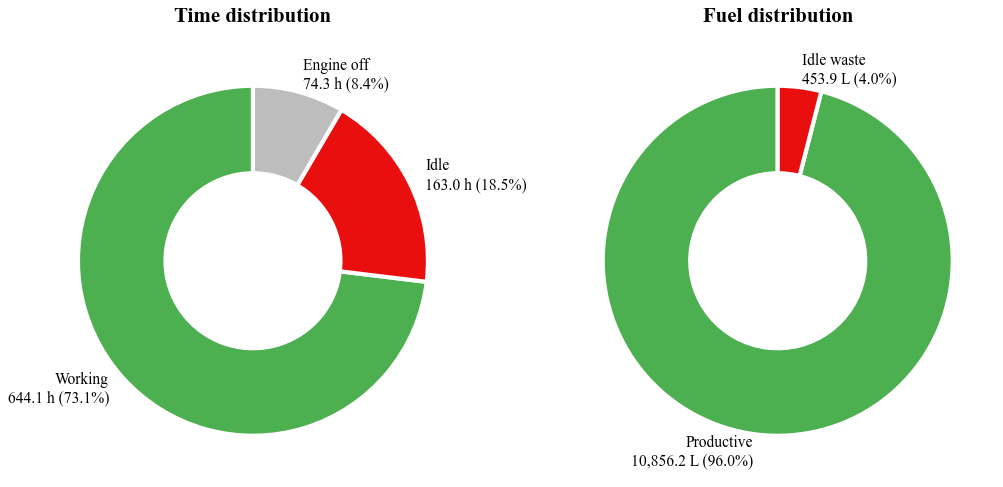

In [28]:
# ==========================================================================
# CELL 9: FIGURE 3 — Global operational balance (donut charts)
# ==========================================================================

# Aggregate from real data
total_h_all = df['delta_t'].sum() / 3600
off_h       = df.loc[df['state'] == 'Off',     'delta_t'].sum() / 3600
idle_h_val  = df.loc[df['state'] == 'Idle',    'delta_t'].sum() / 3600
work_h      = total_h_all - off_h - idle_h_val

total_L_val = df['liters_consumed'].sum()
idle_L_val  = df['fuel_idle'].sum()
prod_L      = total_L_val - idle_L_val

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(7, 3.5))

# -- Left: Time distribution --
time_vals   = [work_h, idle_h_val, off_h]
time_labels = [
    f'Working\n{work_h:,.1f} h ({100*work_h/total_h_all:.1f}%)',
    f'Idle\n{idle_h_val:,.1f} h ({100*idle_h_val/total_h_all:.1f}%)',
    f'Engine off\n{off_h:,.1f} h ({100*off_h/total_h_all:.1f}%)',
]
time_cols = ['#4CAF50', '#EA0F0F', '#BDBDBD']

ax3a.pie(
    time_vals, labels=time_labels, colors=time_cols,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=7.5),
)
ax3a.set_title('Time distribution', fontsize=10, fontweight='bold', pad=10)

# -- Right: Fuel distribution --
fuel_vals   = [prod_L, idle_L_val]
fuel_labels = [
    f'Productive\n{prod_L:,.1f} L ({100*prod_L/total_L_val:.1f}%)',
    f'Idle waste\n{idle_L_val:,.1f} L ({100*idle_L_val/total_L_val:.1f}%)',
]
fuel_cols = ['#4CAF50', "#EA0F0F"]

ax3b.pie(
    fuel_vals, labels=fuel_labels, colors=fuel_cols,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=7.5),
)
ax3b.set_title('Fuel distribution', fontsize=10, fontweight='bold', pad=10)

plt.tight_layout()
save_journal_fig(fig3, 'Figure_3')
plt.show()

  -> Figure_4.tiff + .png  |  1730 x 976 px  |  5.8 x 3.3 in @ 300 dpi


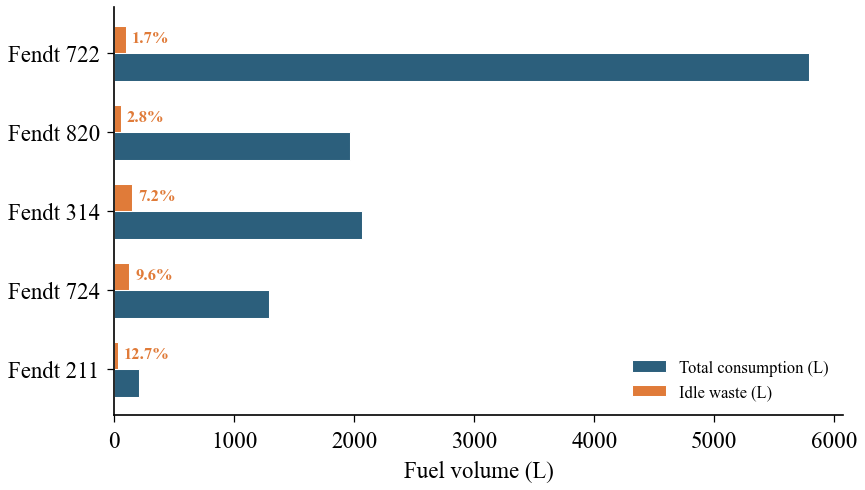

In [22]:
# ==========================================================================
# CELL 10: FIGURE 4 — Tractor total consumption vs idle waste
# ==========================================================================

perf = df.groupby('tractor').agg(
    total_L = ('liters_consumed', 'sum'),
    idle_L  = ('fuel_idle', 'sum'),
).reset_index()
perf['waste_pct'] = (100 * perf['idle_L'] / perf['total_L']).round(1)
perf = perf.sort_values('waste_pct', ascending=True)  # most efficient on top

fig4, ax4 = plt.subplots(figsize=(6, 3.5))

y_pos = np.arange(len(perf))
bar_h = 0.35

ax4.barh(y_pos + bar_h/2, perf['total_L'].values, bar_h,
         label='Total consumption (L)', color='#2C5F7C',
         edgecolor='white', linewidth=0.5)

ax4.barh(y_pos - bar_h/2, perf['idle_L'].values, bar_h,
         label='Idle waste (L)', color='#E07B39',
         edgecolor='white', linewidth=0.5)

# Annotate waste percentage
for i, (_, row) in enumerate(perf.iterrows()):
    ax4.text(
        row['idle_L'] + 50, y_pos[i] - bar_h/2,
        f'{row["waste_pct"]}%',
        va='center', fontsize=8, color='#E07B39', fontweight='bold',
    )

ax4.set_yticks(y_pos)
ax4.set_yticklabels(perf['tractor'].values)
ax4.set_xlabel('Fuel volume (L)')
ax4.legend(loc='lower right', frameon=False, fontsize=8)
ax4.invert_yaxis()

plt.tight_layout()
save_journal_fig(fig4, 'Figure_4')
plt.show()

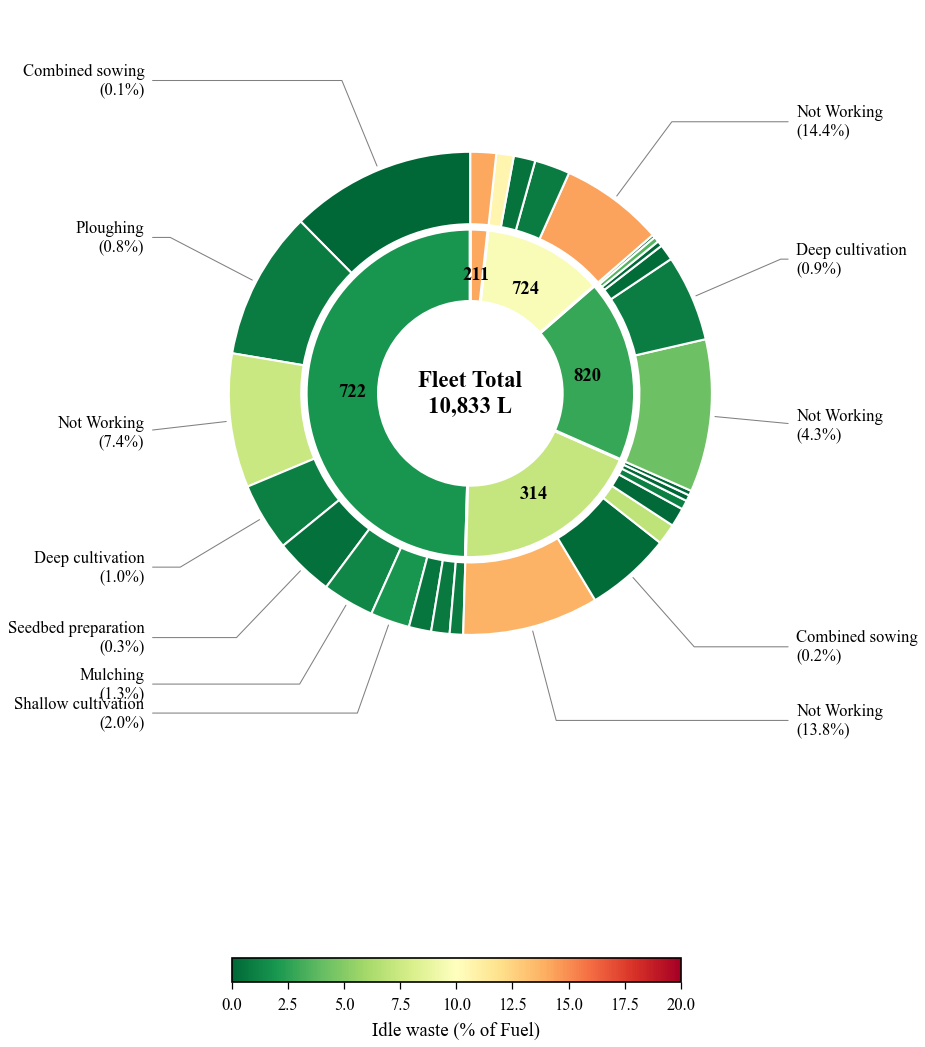

In [ ]:
# ==========================================================================
# CELL 11: FIGURE 5 — Sunburst: Tractor x Activity efficiency profile
# ==========================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. DATA PREP
# --------------------------------------------------------------------------
# Group by Tractor + Activity (English)
raw_profile = df[df['state'] != 'Off'].groupby(['tractor', 'activity_en']).agg(
    total_L  = ('liters_consumed', 'sum'),
    idle_L   = ('fuel_idle', 'sum'),
).reset_index()

# Calculate Waste %
raw_profile['waste_pct'] = (100 * raw_profile['idle_L'] / raw_profile['total_L']).fillna(0)

# FILTERING:
# Remove rows with negligible consumption (< 20 L total)
profile = raw_profile[raw_profile['total_L'] > 20].copy()

# Sort Tractors by Total Consumption
tractor_order_sb = (
    profile.groupby('tractor')['total_L'].sum()
    .sort_values(ascending=False).index.tolist()
)

# 2. COLOR SETUP (0% to 15%)
# --------------------------------------------------------------------------
# RdYlGn_r: Red (High) -> Yellow -> Green (Low)
cmap_sb = plt.cm.RdYlGn_r 
# Adjusted Scale: 0% = Green, 15% = Max Red
norm_sb = mcolors.Normalize(vmin=0, vmax=15) 

# 3. PLOTTING
# --------------------------------------------------------------------------
# Reduced height slightly to remove bottom gap
fig5, ax5 = plt.subplots(figsize=(190/25.4, 200/25.4)) 

# --- INNER RING (Tractors) ---
inner_counts = []
inner_colors = []
inner_labels = []

for t in tractor_order_sb:
    sub = profile[profile['tractor'] == t]
    total_val = sub['total_L'].sum()
    
    # Weighted average waste
    avg_waste = (sub['idle_L'].sum() / total_val) * 100
    
    inner_counts.append(total_val)
    inner_colors.append(cmap_sb(norm_sb(avg_waste)))
    inner_labels.append(t.replace('Fendt ', ''))

# Draw Inner
wedges_in, texts_in = ax5.pie(
    inner_counts, 
    radius=0.68, 
    colors=inner_colors, 
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=1.5), 
    startangle=90,
    labels=inner_labels,
    labeldistance=0.72, 
    textprops=dict(color='black', fontweight='bold', fontsize=9, ha='center', va='center')
)

# --- OUTER RING (Activities) ---
outer_counts = []
outer_colors = []
outer_labels = []

for t in tractor_order_sb:
    # Sort activities by size
    sub = profile[profile['tractor'] == t].sort_values('total_L', ascending=False)
    
    for _, row in sub.iterrows():
        outer_counts.append(row['total_L'])
        outer_colors.append(cmap_sb(norm_sb(row['waste_pct'])))
        
        # Label: "Activity\n(5.2%)"
        lbl = f"{row['activity_en']}\n({row['waste_pct']:.1f}%)"
        outer_labels.append(lbl)

# Draw Outer
wedges_out, _ = ax5.pie(
    outer_counts, 
    radius=1.0, 
    colors=outer_colors, 
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=1.0), 
    startangle=90,
    labels=None 
)

# --- SMART LABELING ENGINE ---
# --------------------------------------------------------------------------
label_data = []

for i, w in enumerate(wedges_out):
    span = w.theta2 - w.theta1
    mid_angle = (w.theta2 - w.theta1) / 2. + w.theta1
    
    # Threshold: Only label if slice is > 2.5% of chart
    if span > (360 * 0.025): 
        x_edge = np.cos(np.deg2rad(mid_angle))
        y_edge = np.sin(np.deg2rad(mid_angle))
        is_right = x_edge >= 0
        
        label_data.append({
            'text': outer_labels[i],
            'angle': mid_angle,
            'x_edge': x_edge,
            'y_edge': y_edge,
            'is_right': is_right,
            'y_final': y_edge * 1.35 # Slightly tighter radius
        })

# Vertical Repulsion
def relax_positions(items, min_dist=0.12):
    if not items: return items
    items.sort(key=lambda x: x['y_final'])
    for _ in range(5): 
        for i in range(len(items) - 1):
            curr = items[i]
            next_item = items[i+1]
            dist = next_item['y_final'] - curr['y_final']
            if dist < min_dist:
                overlap = min_dist - dist
                curr['y_final'] -= overlap / 2
                next_item['y_final'] += overlap / 2
    return items

left_labels = relax_positions([l for l in label_data if not l['is_right']])
right_labels = relax_positions([l for l in label_data if l['is_right']])
all_labels_adjusted = left_labels + right_labels

# Draw Labels
for item in all_labels_adjusted:
    x_text_anchor = 1.35 if item['is_right'] else -1.35
    y_text_anchor = item['y_final']
    ha = 'left' if item['is_right'] else 'right'
    
    ax5.annotate(
        item['text'],
        xy=(item['x_edge'], item['y_edge']),
        xytext=(x_text_anchor, y_text_anchor),
        horizontalalignment=ha,
        verticalalignment='center',
        fontsize=8,
        arrowprops=dict(
            arrowstyle="-",
            connectionstyle=f"angle,angleA=0,angleB={item['angle']}",
            color='gray',
            lw=0.5
        )
    )

# 4. CENTER TEXT
fleet_total = sum(inner_counts)
ax5.text(0, 0, f'Fleet Total\n{fleet_total:,.0f} L',
         ha='center', va='center', fontsize=11, fontweight='bold')

# 5. COLORBAR (Moved Closer to Chart)
sm = plt.cm.ScalarMappable(cmap=cmap_sb, norm=norm_sb)
sm.set_array([])

# Position: [left, bottom, width, height]
# Moved bottom from 0.02 to 0.08 to close the gap
cbar_ax = fig5.add_axes([0.3, 0.08, 0.4, 0.02]) 
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Idle waste (% of Fuel)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Final Limits
ax5.set_xlim(-1.8, 1.8)
ax5.set_ylim(-1.5, 1.5)

save_journal_fig(fig5, 'Figure_5')
plt.show()

In [24]:
# ==========================================================================
# CELL 11: Export Summary
# ==========================================================================
print('=' * 60)
print('  JOURNAL FIGURE EXPORT COMPLETE')
print('=' * 60)
print(f'Output: {FIG_DIR}\n')

for f in sorted(FIG_DIR.glob('Figure_*')):
    size_kb = f.stat().st_size / 1024
    if f.suffix == '.png':
        img = Image.open(f)
        w, h = img.size
        print(f'  {f.name:<20}  {w}x{h} px  '
              f'({w/300:.1f}x{h/300:.1f} in @ 300 dpi)  '
              f'{size_kb:,.0f} KB')
    else:
        print(f'  {f.name:<20}  {size_kb:,.0f} KB  (TIFF for submission)')

print('\n--- Submission reminders ---')
print('  1. Upload .tiff files as separate figure files')
print('  2. Captions go in the manuscript, not on the figure')
print('  3. Check readability at single-column width (88 mm / 3.46 in)')

  JOURNAL FIGURE EXPORT COMPLETE
Output: e:\Tese\idletime\reports\journal_figures

  Figure_1.png          1577x1125 px  (5.3x3.8 in @ 300 dpi)  54 KB
  Figure_1.tiff         6,930 KB  (TIFF for submission)
  Figure_2.png          2177x1278 px  (7.3x4.3 in @ 300 dpi)  149 KB
  Figure_2.tiff         10,868 KB  (TIFF for submission)
  Figure_3.png          2008x974 px  (6.7x3.2 in @ 300 dpi)  104 KB
  Figure_3.tiff         7,640 KB  (TIFF for submission)
  Figure_4.png          1730x976 px  (5.8x3.3 in @ 300 dpi)  64 KB
  Figure_4.tiff         6,596 KB  (TIFF for submission)
  Figure_5.png          2551x1894 px  (8.5x6.3 in @ 300 dpi)  297 KB
  Figure_5.tiff         18,874 KB  (TIFF for submission)

--- Submission reminders ---
  1. Upload .tiff files as separate figure files
  2. Captions go in the manuscript, not on the figure
  3. Check readability at single-column width (88 mm / 3.46 in)
